### Friction Surface EDA

**Question:** what do the Malaria Atlas Project friction surfaces (Weiss et al., 2020) actually say about travel in South Sudan? This is the layer that drives every travel time in the access model.

**Data:** two global rasters giving the time (in minutes) needed to cross one metre, a *walking-only* version and a *motorised* version (motorised where roads exist, walking elsewhere). Both are 2020.

**Approach**
1. Read both rasters at their native ~1 km resolution, only the window around South Sudan.
2. Convert minutes per metre into km/h, which is easier to judge.
3. Check: what speeds occur, how much motorised transport helps, whether anything is impassable, and what happens at the White Nile.
4. Summarise per county.

**Read before interpreting**
* `km/h = 60 / (friction × 1000)`. A friction of 0.012 min/m is 5 km/h.
* This notebook looks at the source data, not at our 250 m grid. The numbers carry over, because the 250 m stack copies these values unchanged (nearest neighbour).

In [1]:
import os
from pathlib import Path

# Work from the repo root so the raw_data paths resolve the same way as in the other notebooks
REPO = Path.cwd().resolve()
while not (REPO / "raw_data").is_dir():
    if REPO == REPO.parent:
        raise FileNotFoundError("Repo root (folder containing raw_data/) not found")
    REPO = REPO.parent
os.chdir(REPO)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import Resampling, reproject
from rasterio.windows import from_bounds, transform as window_transform

RAW = REPO / "raw_data"
FRICTION = {
    "walking": RAW / "map_friction_maps" / "2020_walking_only_friction_surface.geotiff",
    "motorised": RAW / "map_friction_maps" / "2020_motorized_friction_surface.geotiff",
}
POP = RAW / "worldpop" / "ssd_pop_2020_CN_100m_R2025A_v1.tif"
ADMIN2 = RAW / "Administrative boundaries" / "ssd_admin2.geojson"
OUT = REPO / "EDA" / "outputs"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

BBOX = (23.4, 3.4, 36.0, 12.3)   # South Sudan; the friction rasters are global

# chart styling, shared with the other EDA figures (blue/orange pair validated for colour-blind readers)
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
WALK, MOTO = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
print("repo root:", REPO)

repo root: C:\Users\nikol\Documents\Capstone_CBL\JBG060_ZHL_2026_Group19


#### 1. Raster properties
Both files cover the whole world, so only the window around South Sudan is read. Nodata (-9999, the oceans) becomes NaN.

In [2]:
def read_window(path):
    """Read the South Sudan window of a global raster; nodata becomes NaN."""
    with rasterio.open(path) as src:
        win = from_bounds(*BBOX, src.transform)
        arr = src.read(1, window=win).astype("float32")
        arr[arr == src.nodata] = np.nan
        print(f"{path.name}\n    crs={src.crs}  res={src.res[0]:.6f} deg (~{src.res[0] * 111:.2f} km)  "
              f"dtype={src.dtypes[0]}  nodata={src.nodata}\n    global shape={src.shape}, "
              f"South Sudan window={arr.shape}")
        return arr, window_transform(win, src.transform), src.crs

def kmh(friction):
    """Convert minutes per metre to km/h."""
    with np.errstate(divide="ignore", invalid="ignore"):
        return 60 / (friction * 1000)

walk, tf, crs = read_window(FRICTION["walking"])
moto, tf_m, _ = read_window(FRICTION["motorised"])
assert tf == tf_m and walk.shape == moto.shape, "the two friction layers are not on one grid"

2020_walking_only_friction_surface.geotiff
    crs=EPSG:4326  res=0.008333 deg (~0.92 km)  dtype=float32  nodata=-9999.0
    global shape=(17400, 43200), South Sudan window=(1068, 1512)
2020_motorized_friction_surface.geotiff
    crs=EPSG:4326  res=0.008333 deg (~0.92 km)  dtype=float32  nodata=-9999.0
    global shape=(17400, 43200), South Sudan window=(1068, 1512)


Mark which cells fall inside South Sudan by burning the county polygons onto the same grid. Each cell gets its county number (1 to 79), or 0 outside the country.

In [3]:
adm2 = gpd.read_file(ADMIN2)
labels = rasterize(((geom, i + 1) for i, geom in enumerate(adm2.to_crs(crs).geometry)),
                   out_shape=walk.shape, transform=tf, fill=0, dtype="int32")
inside = labels > 0
print(f"cells inside South Sudan: {inside.sum():,} of {walk.size:,}")
print(f"nodata inside South Sudan: walking {np.isnan(walk[inside]).sum()}, motorised {np.isnan(moto[inside]).sum()}")

cells inside South Sudan: 758,518 of 1,614,816
nodata inside South Sudan: walking 0, motorised 0


#### 2. What speeds do these values imply?
Percentiles of friction inside South Sudan, with the speed each one corresponds to.

In [4]:
pct = [0, 1, 5, 25, 50, 75, 95, 99, 100]
dist = pd.DataFrame({
    mode: pd.Series(np.percentile(arr[inside], pct), index=[f"p{p}" for p in pct])
    for mode, arr in [("walking", walk), ("motorised", moto)]
})
for mode in ["walking", "motorised"]:
    dist[f"{mode} km/h"] = kmh(dist[mode]).round(2)
display(dist.round(5))
print(f"walking is capped at {kmh(walk[inside].min()):.1f} km/h and never drops below {kmh(walk[inside].max()):.2f} km/h")

,walking,motorised,walking km/h,motorised km/h
p0,0.01200,0.00075,5.00,80.47
p1,0.01200,0.00100,5.00,60.00
p5,0.01200,0.00120,5.00,50.00
p25,0.01265,0.01265,4.74,4.74
p50,0.01291,0.01289,4.65,4.65
p75,0.01349,0.01348,4.45,4.45
p95,0.02478,0.02476,2.42,2.42
p99,0.04616,0.03092,1.30,1.94
p100,0.17882,0.17882,0.34,0.34


walking is capped at 5.0 km/h and never drops below 0.34 km/h


Walking speed barely varies: three quarters of the country sits between 4.45 and 5 km/h. Motorised only departs from walking in the fastest 5–10% of cells, which are the roads.

#### 3. How much does motorised transport help?
Off-road, the motorised surface falls back to walking, so the two layers are often identical. Population (WorldPop 2020, summed onto the same ~1 km grid) shows how many people that affects.

In [5]:
def load_population(shape, tf, crs):
    """WorldPop 2020 summed onto the friction grid, so cells can be weighted by people."""
    out = np.full(shape, np.nan, dtype="float32")
    with rasterio.open(POP) as src:
        reproject(source=rasterio.band(src, 1), destination=out, dst_transform=tf, dst_crs=crs,
                  src_nodata=src.nodata, dst_nodata=np.nan, resampling=Resampling.sum)
    return np.nan_to_num(out)

same = (moto == walk) & inside
slower = (moto > walk) & inside
pop = load_population(walk.shape, tf, crs)

print(f"identical to walking:       {same.sum():>9,} cells ({same.sum() / inside.sum():.1%})")
print(f"motorised SLOWER than walk: {slower.sum():>9,} cells ({slower.sum() / inside.sum():.2%}), "
      f"by up to {(moto[slower] / walk[slower]).max():.1f}x")
print(f"population living where motorised gives no advantage: "
      f"{pop[same].sum():,.0f} of {pop[inside].sum():,.0f} ({pop[same].sum() / pop[inside].sum():.1%})")

identical to walking:         676,061 cells (89.1%)
motorised SLOWER than walk:     3,791 cells (0.50%), by up to 5.0x
population living where motorised gives no advantage: 4,059,073 of 10,509,966 (38.6%)


Motorised being *slower* than walking can't be true in reality; it's an artefact of how the motorised surface was built. For the motorised mode we should take the cell-wise minimum of the two layers, or at least state it.

#### 4. Is anything impassable?
In a least-cost travel model only an infinite (or extremely high) cost stops a path. How slow does it get?

In [6]:
for cut in [0.05, 0.1, 0.15]:
    n = (walk[inside] > cut).sum()
    print(f"walking slower than {kmh(cut):.2f} km/h: {n:>6,} cells ({n / inside.sum():.3%})")
print(f"\nslowest cell in the country: {kmh(np.nanmax(walk[inside])):.2f} km/h")

walking slower than 1.20 km/h:  7,427 cells (0.979%)
walking slower than 0.60 km/h:     99 cells (0.013%)
walking slower than 0.40 km/h:     20 cells (0.003%)

slowest cell in the country: 0.34 km/h


**Nothing is impassable.** The slowest cell is still 0.34 km/h, so every river, swamp and lake can be crossed in the model.

#### 5. The White Nile: is the river a barrier?
Sample walking speed along west-east lines crossing the river at three towns. If the river were treated as water, speed should drop sharply (or to zero) where the line crosses it.

Juba     lat 4.85: slowest cell 4.68 km/h (median 5.00 km/h)
Bor      lat 6.21: slowest cell 1.00 km/h (median 5.00 km/h)
Malakal  lat 9.53: slowest cell 2.43 km/h (median 4.75 km/h)


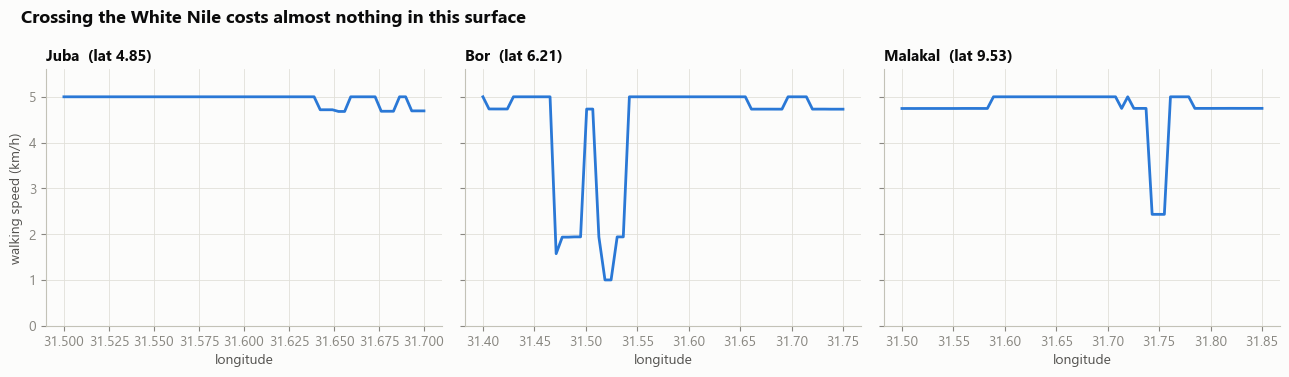

In [7]:
TRANSECTS = {"Juba": (4.85, 31.50, 31.70), "Bor": (6.21, 31.40, 31.75), "Malakal": (9.53, 31.50, 31.85)}

def sample_row(arr, tf, lat, lon0, lon1, n=60):
    """Sample a raster along a west-east line, returning the longitudes and values."""
    lon = np.linspace(lon0, lon1, n)
    col = ((lon - tf.c) / tf.a).astype(int)
    row = int((lat - tf.f) / tf.e)
    return lon, arr[row, col]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (name, (lat, lon0, lon1)) in zip(axes, TRANSECTS.items()):
    lon, v = sample_row(walk, tf, lat, lon0, lon1)
    print(f"{name:8s} lat {lat}: slowest cell {kmh(np.nanmax(v)):.2f} km/h (median {kmh(np.nanmedian(v)):.2f} km/h)")
    ax.plot(lon, kmh(v), color=WALK, lw=2)
    ax.set_title(f"{name}  (lat {lat})", loc="left")
    ax.set_xlabel("longitude")
axes[0].set_ylabel("walking speed (km/h)")
axes[0].set_ylim(0, 5.6)
fig.suptitle("Crossing the White Nile costs almost nothing in this surface", x=0.02, ha="left",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "friction_nile_transects.png", dpi=200)
plt.show()

At Juba the river is invisible: the walk across it runs at 4.7–5 km/h, as on dry land. At Bor and Malakal there is a slowdown, but the river can still be crossed in well under an hour.

We need an external permanent-water layer (e.g. JRC Global Surface Water).

#### 6. Maps
Speed capped at 30 km/h for display so the roads stand out without washing out the rest.

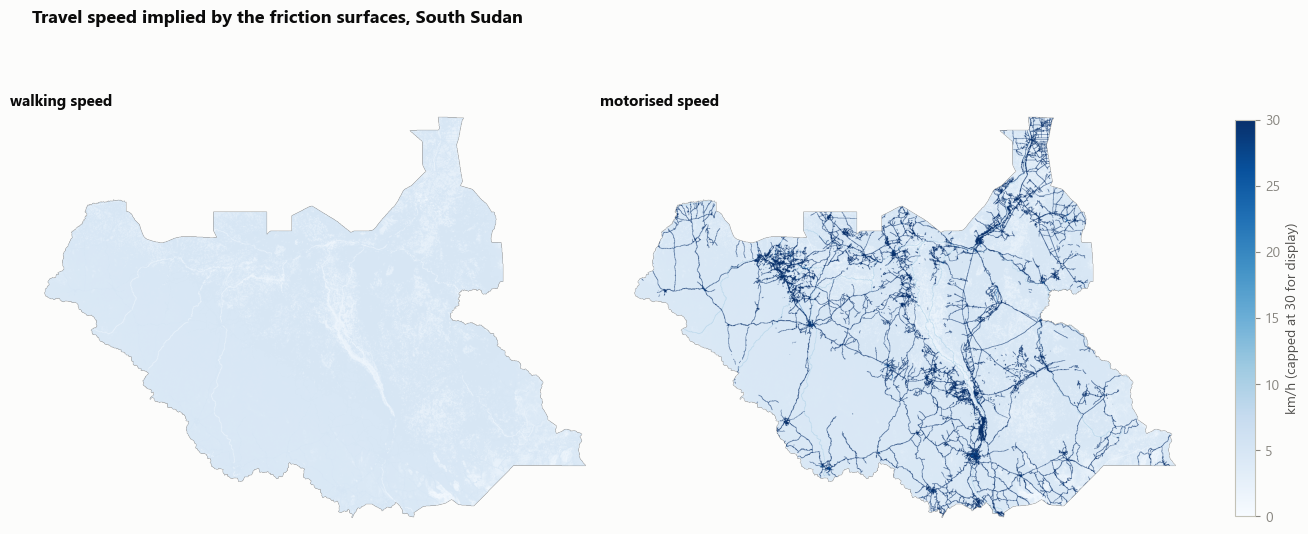

In [8]:
def extent(arr, tf):
    return (tf.c, tf.c + arr.shape[1] * tf.a, tf.f + arr.shape[0] * tf.e, tf.f)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), layout="constrained")
for ax, (mode, arr) in zip(axes, [("walking", walk), ("motorised", moto)]):
    im = ax.imshow(kmh(np.where(inside, arr, np.nan)), extent=extent(arr, tf), cmap="Blues", vmin=0, vmax=30)
    ax.set_title(f"{mode} speed", loc="left")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
fig.colorbar(im, ax=axes, shrink=0.7, label="km/h (capped at 30 for display)")
fig.suptitle("Travel speed implied by the friction surfaces, South Sudan", x=0.02, ha="left",
             fontsize=13, fontweight="bold")
fig.savefig(FIG / "friction_speed_maps.png", dpi=200)
plt.show()

#### 7. Distribution of speeds
Share of cells at or below each speed. The two curves sit on top of each other below 5 km/h, so walking is drawn thick underneath and motorised thin on top.

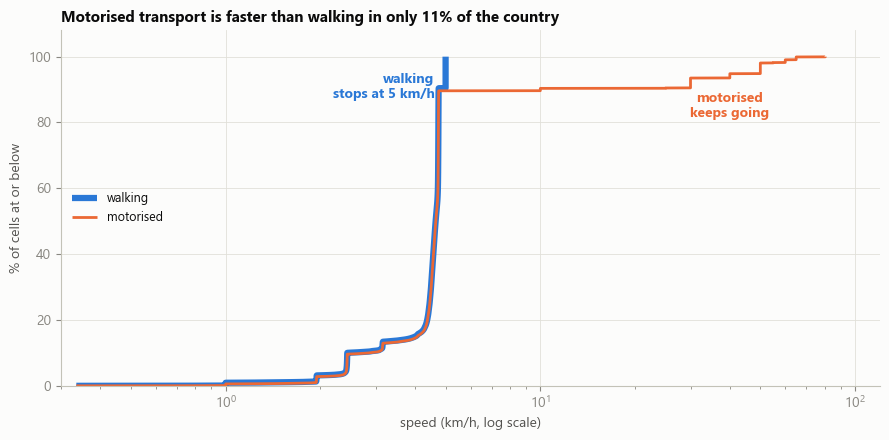

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
curves = {}
for (mode, arr), col, lw in [(("walking", walk), WALK, 4.5), (("motorised", moto), MOTO, 2)]:
    v = np.sort(kmh(arr[inside]))
    curves[mode] = v
    ax.plot(v, np.linspace(0, 100, v.size), color=col, lw=lw, label=mode, solid_capstyle="butt")
ax.annotate("walking\nstops at 5 km/h", (curves["walking"][-1], 100), xytext=(-8, -30),
            textcoords="offset points", color=WALK, fontsize=10, fontweight="bold", ha="right")
ax.annotate("motorised\nkeeps going", (40, 96), xytext=(0, -34), textcoords="offset points",
            color=MOTO, fontsize=10, fontweight="bold", ha="center")
ax.set_xscale("log")
ax.set_xlim(0.3, 120); ax.set_ylim(0, 108)
ax.set_xlabel("speed (km/h, log scale)"); ax.set_ylabel("% of cells at or below")
ax.set_title("Motorised transport is faster than walking in only 11% of the country", loc="left")
ax.legend(loc="center left", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "friction_speed_distribution.png", dpi=200)
plt.show()

#### 8. By county
Median speed per county, and the share of each county's cells where motorised transport gives no advantage (no road).

In [10]:
n = len(adm2)
county = pd.DataFrame({
    "adm2_name": adm2["adm2_name"], "adm2_pcode": adm2["adm2_pcode"], "adm1_name": adm2["adm1_name"],
    "cells": np.bincount(labels.ravel(), minlength=n + 1)[1:],
})
for mode, arr in [("walking", walk), ("motorised", moto)]:
    county[f"median_kmh_{mode}"] = [round(float(kmh(np.nanmedian(arr[labels == i + 1]))), 2) for i in range(n)]
county["pct_cells_no_road"] = [round(100 * float(same[labels == i + 1].mean()), 1) for i in range(n)]
county = county.sort_values("median_kmh_walking").reset_index(drop=True)
county.to_csv(OUT / "friction_by_county.csv", index=False)
display(county.head(15))
print(f"median walking speed across counties: {county['median_kmh_walking'].min()} to {county['median_kmh_walking'].max()} km/h")

,adm2_name,adm2_pcode,adm1_name,cells,median_kmh_walking,median_kmh_motorised,pct_cells_no_road
0,Renk,SS0711,Upper Nile,11949,4.08,4.04,73.5
1,Kapoeta East,SS0203,Eastern Equatoria,34709,4.15,4.16,92.7
2,Morobo,SS0104,Central Equatoria,1538,4.29,4.27,68.4
3,Budi,SS0201,Eastern Equatoria,6727,4.31,4.31,89.6
4,Ikotos,SS0202,Eastern Equatoria,4120,4.31,4.30,85.2
5,Kajo-keji,SS0102,Central Equatoria,2954,4.31,4.31,68.8
6,Kapoeta South,SS0205,Eastern Equatoria,1407,4.34,4.34,84.9
7,Magwi,SS0207,Eastern Equatoria,6100,4.37,4.37,81.7
8,Lainya,SS0103,Central Equatoria,4098,4.40,4.40,87.7
9,Yei,SS0106,Central Equatoria,7891,4.43,4.43,86.9


median walking speed across counties: 4.08 to 4.75 km/h


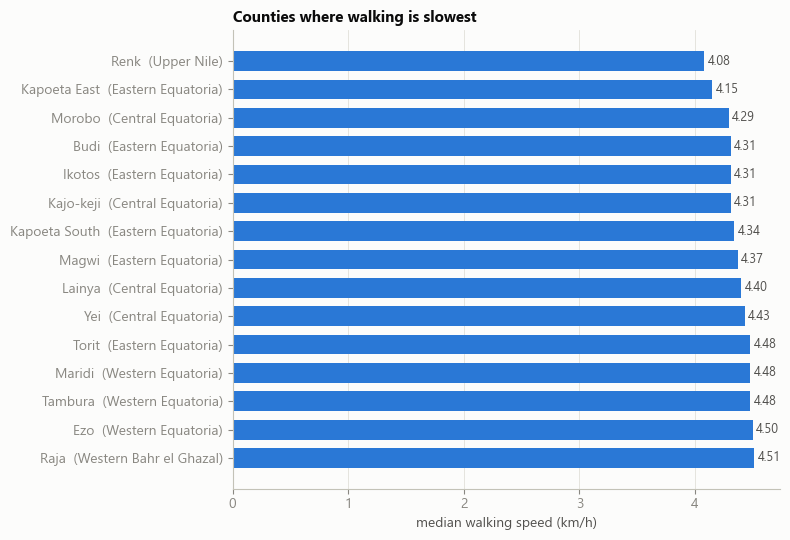

In [11]:
top = county.head(15)[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["adm2_name"] + "  (" + top["adm1_name"] + ")", top["median_kmh_walking"], height=0.7, color=WALK)
for y_, v in enumerate(top["median_kmh_walking"]):
    ax.text(v + 0.03, y_, f"{v:.2f}", va="center", fontsize=9, color=INK2)
ax.set_xlabel("median walking speed (km/h)")
ax.grid(axis="y", visible=False)
ax.set_title("Counties where walking is slowest", loc="left")
fig.tight_layout()
fig.savefig(FIG / "friction_slowest_counties.png", dpi=200)
plt.show()

The bars are nearly the same length, and that is the finding: even the slowest county walks at about 4.1 km/h, and the fastest at about 4.75.

#### What this means for the access model
1. **Water is not a barrier.** Nothing is impassable, and the White Nile at Juba is crossed as if it were dry land. Without a permanent-water mask the model walks people across rivers and the Sudd. This has to be fixed before any baseline run.
2. **Walking is nearly uniform.** Walking travel time will be close to straight-line distance divided by ~4.6 km/h; differences between counties come mostly from how far apart facilities are, not from terrain.
3. **Motorised barely differs from walking.** Identical in 89% of the country; 39% of people live where it gives no advantage.
4. **Motorised is slower than walking in 0.5% of cells**, by up to 5×. Use cell-wise minimum of the two layers for the motorised mode.
5. **A 2020 snapshot under normal conditions.** It can't show roads built or destroyed in that period, and it assumes dry roads: flood effects have to be added by us.